 Financial Risk Analytics & Bankruptcy Prediction
 project using SQL concepts, Python, ML and Power BI.

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('customers.csv')
accounts = pd.read_csv('accounts.csv')
loans = pd.read_csv('loans.csv')
transactions = pd.read_csv('transactions.csv')



In [13]:

# Basic checks
for name, df in {
    'customers': customers.columns,
    'accounts': accounts.columns,
    'loans': loans.columns,
    'transactions': transactions.columns,
    
}.items():
    print(name, df)


customers Index(['Customer_ID', 'Age', 'Gender', 'Region', 'Employment_Status',
       'Annual_Income', 'Dependents'],
      dtype='object')
accounts Index(['Account_ID', 'Customer_ID', 'Account_Type', 'Account_Balance',
       'Account_Status'],
      dtype='object')
loans Index(['Loan_ID', 'Customer_ID', 'Loan_Type', 'Loan_Amount',
       'Outstanding_Debt', 'Interest_Rate', 'Monthly_EMI', 'Missed_Payments'],
      dtype='object')
transactions Index(['Transaction_ID', 'Account_ID', 'Transaction_Type', 'Amount',
       'Merchant_Category', 'Channel'],
      dtype='object')


In [14]:
customers['monthly_income'] = customers['Annual_Income'] / 12

In [15]:
avg_txn = transactions.groupby('Account_ID')['Amount'].mean().reset_index(name='Avg_Transaction')

In [16]:
total_txn = transactions.groupby('Account_ID')['Amount'].sum().reset_index(name='Total_Amount')

In [17]:
accounts = accounts.merge(avg_txn, on='Account_ID', how='left')

In [18]:
accounts = accounts.merge(total_txn, on='Account_ID', how='left')

In [23]:
df = customers.merge(loans, on='Customer_ID', how='left')
df = df.merge(accounts, on='Customer_ID', how='left')
df.head()
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Region', 'Employment_Status',
       'Annual_Income', 'Dependents', 'monthly_income', 'Loan_ID', 'Loan_Type',
       'Loan_Amount', 'Outstanding_Debt', 'Interest_Rate', 'Monthly_EMI',
       'Missed_Payments', 'Account_ID', 'Account_Type', 'Account_Balance',
       'Account_Status', 'Avg_Transaction', 'Total_Amount'],
      dtype='object')

In [24]:

model_df = df[[
'Age','Annual_Income','Dependents','monthly_income',
'Account_Balance','Loan_Amount','Outstanding_Debt',
'Interest_Rate','Monthly_EMI','Missed_Payments',
'Avg_Transaction','Total_Amount'
]].dropna()


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [26]:
X = model_df.drop('Bankruptcy_Risk', axis=1)

KeyError: "['Bankruptcy_Risk'] not found in axis"

In [ ]:
y = model_df['Bankruptcy_Risk']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:
scaler = StandardScaler()

In [44]:
X_train = scaler.fit_transform(X_train)

In [45]:
X_test = scaler.transform(X_test)


In [46]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
y_pred = model.predict(X_test)
print("Accuracy:", 100*accuracy_score(y_test, y_pred))



Accuracy: 83.33333333333334


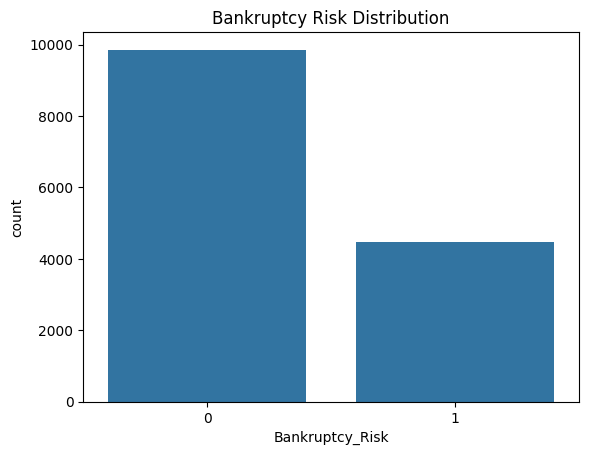

In [48]:

sns.countplot(x='Bankruptcy_Risk', data=model_df)
plt.title('Bankruptcy Risk Distribution')
plt.show()
